# 04 - Model Optimization (Stage 7)
Hyperparameter tuning, imbalance/threshold optimisation, final model selection, and saving the
deployment model. Self-contained — no `src/train.py` is used; everything is defined in this notebook.

**Tuning is split 1 model each for 3 members + 1 model for the repo owner (7 models, 4 people):**
Member 4 -> RandomForest  |  Member 1 -> LogisticRegression, DecisionTree
Member 2 -> HistGradientBoosting, XGBoost  |  Member 3 -> SVM_RBF, KNN

In [1]:
import os, sys, warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

# os.environ["FAST"] = "1"   # <- uncomment for a quick dry run (small sample, 3 folds, few search iterations)

import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from src.preprocessing import (BEST_PREP, FEATURE_COLS, MODELS_DIR, N_JOBS, RANDOM_STATE, TARGET,
                               get_split, load_clean, make_preprocessing_steps)
from src.evaluate import best_f_threshold, get_cv, holdout_metrics, maybe_subsample, save_fig, save_table

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

try:
    from imblearn.pipeline import Pipeline as ImbPipeline  # noqa: F401 (not needed for final tuned pipelines)
    HAS_IMBLEARN = True
except Exception:
    HAS_IMBLEARN = False

sns.set_theme(style="whitegrid")
X_train, X_test, y_train, y_test = get_split()
X_train_cv, y_train_cv = maybe_subsample(X_train, y_train)
print("BEST_PREP:", BEST_PREP)
print("train:", X_train.shape, "test:", X_test.shape)

BEST_PREP: {'imputer': 'median', 'cat_imputer': 'mode', 'outlier': 'log', 'scale': True, 'use_fe': True, 'selector': None, 'drop_cols': []}
train: (9790, 17) test: (2448, 17)


## 1. Models, pipeline, and search spaces
Redefines the same model zoo and pipeline builder as `03_model_development.ipynb`, plus a tuning
search space for every one of the 7 algorithms, so each can be tuned independently.

In [2]:
def get_models() -> dict:
    models = {
        "LogisticRegression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "DecisionTree": DecisionTreeClassifier(min_samples_leaf=5, random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=1),
        "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
        "SVM_RBF": SVC(kernel="rbf", random_state=RANDOM_STATE),
        "KNN": KNeighborsClassifier(n_neighbors=15),
    }
    if HAS_XGB:
        models["XGBoost"] = XGBClassifier(eval_metric="logloss", tree_method="hist",
                                          random_state=RANDOM_STATE, n_jobs=1)
    return models


def build_pipeline(estimator, imbalance="none", **prep_kwargs):
    est = clone(estimator)
    if imbalance == "class_weight":
        params = est.get_params()
        if "class_weight" in params:
            est.set_params(class_weight="balanced")
        elif "scale_pos_weight" in params:
            est.set_params(scale_pos_weight=5.5)
    steps = make_preprocessing_steps(**prep_kwargs)
    return Pipeline(steps + [("model", est)])


def get_search_spaces() -> dict:
    """name -> (imbalance handling of the base pipeline, search space)."""
    spaces = {
        "LogisticRegression": ("class_weight", {"model__C": loguniform(1e-3, 1e2)}),
        "DecisionTree": ("none", {
            "model__max_depth": [None, 4, 6, 8, 10, 14, 20],
            "model__min_samples_leaf": randint(1, 20), "model__min_samples_split": randint(2, 30),
            "model__criterion": ["gini", "entropy"], "model__class_weight": ["balanced", None]}),
        "RandomForest": ("none", {
            "model__n_estimators": randint(200, 600), "model__max_depth": [None, 8, 12, 16, 24],
            "model__min_samples_leaf": randint(1, 12), "model__max_features": ["sqrt", "log2", 0.3, 0.5],
            "model__class_weight": ["balanced", "balanced_subsample", None]}),
        "HistGradientBoosting": ("none", {
            "model__learning_rate": loguniform(0.02, 0.3), "model__max_iter": randint(100, 500),
            "model__max_leaf_nodes": randint(8, 64), "model__min_samples_leaf": randint(10, 80),
            "model__l2_regularization": loguniform(1e-3, 10), "model__class_weight": ["balanced", None]}),
        "SVM_RBF": ("none", {
            "model__C": loguniform(1e-2, 1e2), "model__gamma": loguniform(1e-4, 1e0),
            "model__class_weight": ["balanced", None]}),
        "KNN": ("none", {
            "model__n_neighbors": randint(5, 50), "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]}),
    }
    if HAS_XGB:
        spaces["XGBoost"] = ("none", {
            "model__n_estimators": randint(150, 600), "model__max_depth": randint(3, 9),
            "model__learning_rate": loguniform(0.02, 0.3), "model__subsample": uniform(0.6, 0.4),
            "model__colsample_bytree": uniform(0.5, 0.5), "model__min_child_weight": randint(1, 10),
            "model__scale_pos_weight": [1, 3, 5.5]})
    return spaces


TUNING_SCORING = {"pr_auc": "average_precision", "roc_auc": "roc_auc", "f1": "f1",
                  "recall": "recall", "precision": "precision"}
from src.preprocessing import FAST
N_ITER = (5 if FAST else 40)  # candidates per model; FAST=1 gives a quick dry run


def tune_one_model(name, X_train, y_train, cv, n_iter=N_ITER, prep=None):
    """Tune exactly ONE model family. Returns (best_params, summary_row, cv_results_df).
    Each member calls this once, for their own model(s), in their own cell below."""
    prep = prep or BEST_PREP
    imb, space = get_search_spaces()[name]
    print(f"Tuning {name}: {n_iter} candidates x CV")
    search = RandomizedSearchCV(build_pipeline(get_models()[name], imb, **prep), space, n_iter=n_iter,
                                scoring=TUNING_SCORING, refit="pr_auc", cv=cv, n_jobs=N_JOBS,
                                random_state=RANDOM_STATE, verbose=1)
    search.fit(X_train, y_train)
    i, r = search.best_index_, search.cv_results_
    best_params = {k: (v.item() if hasattr(v, "item") else v) for k, v in search.best_params_.items()}
    summary_row = {"model": name, "imbalance_base": imb,
                   **{f"cv_{k}": r[f"mean_test_{k}"][i] for k in TUNING_SCORING},
                   "cv_pr_auc_std": r["std_test_pr_auc"][i], "best_params": json.dumps(best_params)}
    return best_params, summary_row, pd.DataFrame(r).sort_values("rank_test_pr_auc")

best_params, tuning_rows, tuning_details = {}, [], {}
print("Ready. Search spaces defined for:", list(get_search_spaces().keys()))

Ready. Search spaces defined for: ['LogisticRegression', 'DecisionTree', 'RandomForest', 'HistGradientBoosting', 'SVM_RBF', 'KNN', 'XGBoost']


## 2. Hyperparameter tuning, one cell per member

### Member 4 - Random Forest (final model)

In [3]:
bp, row, details = tune_one_model("RandomForest", X_train_cv, y_train_cv, cv=get_cv())
best_params["RandomForest"] = bp
tuning_rows.append(row)
tuning_details["RandomForest"] = details
save_table(details, "tuning_cv_results_RandomForest")
print("Best params:", bp)
print("CV PR-AUC:", round(row["cv_pr_auc"], 4))

Tuning RandomForest: 40 candidates x CV
Fitting 5 folds for each of 40 candidates, totalling 200 fits
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuning_cv_results_RandomForest.csv
Best params: {'model__class_weight': None, 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 424}
CV PR-AUC: 0.7526


### Member 1 - Logistic Regression + Decision Tree

In [4]:
for name in ["LogisticRegression", "DecisionTree"]:
    bp, row, details = tune_one_model(name, X_train_cv, y_train_cv, cv=get_cv())
    best_params[name] = bp
    tuning_rows.append(row)
    tuning_details[name] = details
    save_table(details, f"tuning_cv_results_{name}")
    print(name, "best params:", bp)
    print("CV PR-AUC:", round(row["cv_pr_auc"], 4))

Tuning LogisticRegression: 40 candidates x CV
Fitting 5 folds for each of 40 candidates, totalling 200 fits
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuning_cv_results_LogisticRegression.csv
LogisticRegression best params: {'model__C': 0.03334792728637585}
CV PR-AUC: 0.6668
Tuning DecisionTree: 40 candidates x CV
Fitting 5 folds for each of 40 candidates, totalling 200 fits
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuning_cv_results_DecisionTree.csv
DecisionTree best params: {'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': 6, 'model__min_samples_leaf': 19, 'model__min_samples_split': 18}
CV PR-AUC: 0.7016


### Member 2 - HistGradientBoosting + XGBoost

In [6]:
for name in ["HistGradientBoosting", "XGBoost"]:
    if name == "XGBoost" and not HAS_XGB:
        print("XGBoost not installed - skipping"); continue
    bp, row, details = tune_one_model(name, X_train_cv, y_train_cv, cv=get_cv())
    best_params[name] = bp
    tuning_rows.append(row)
    tuning_details[name] = details
    save_table(details, f"tuning_cv_results_{name}")
    print(name, "best params:", bp)
    print("CV PR-AUC:", round(row["cv_pr_auc"], 4))

Tuning HistGradientBoosting: 40 candidates x CV
Fitting 5 folds for each of 40 candidates, totalling 200 fits
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuning_cv_results_HistGradientBoosting.csv
HistGradientBoosting best params: {'model__class_weight': None, 'model__l2_regularization': 0.014926318309209369, 'model__learning_rate': 0.02077730198812756, 'model__max_iter': 180, 'model__max_leaf_nodes': 15, 'model__min_samples_leaf': 44}
CV PR-AUC: 0.7514
Tuning XGBoost: 40 candidates x CV
Fitting 5 folds for each of 40 candidates, totalling 200 fits
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuning_cv_results_XGBoost.csv
XGBoost best params: {'model__colsample_bytree': 0.847892199672541, 'model__learning_rate': 0.03713861285134416, 'model__max_depth': 4, 'model__min_child_weight': 9, 'model__n_estimators': 209, 'model__scale_pos_weight': 1, 'model__subsample': 0.6967409163601807}
CV PR-AUC: 0.7512


### Member 3 - SVM + KNN

In [7]:
for name in ["SVM_RBF", "KNN"]:
    bp, row, details = tune_one_model(name, X_train_cv, y_train_cv, cv=get_cv())
    best_params[name] = bp
    tuning_rows.append(row)
    tuning_details[name] = details
    save_table(details, f"tuning_cv_results_{name}")
    print(name, "best params:", bp)
    print("CV PR-AUC:", round(row["cv_pr_auc"], 4))

Tuning SVM_RBF: 40 candidates x CV
Fitting 5 folds for each of 40 candidates, totalling 200 fits
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuning_cv_results_SVM_RBF.csv
SVM_RBF best params: {'model__C': 28.34090429514775, 'model__class_weight': None, 'model__gamma': 0.00627773091695805}
CV PR-AUC: 0.7253
Tuning KNN: 40 candidates x CV
Fitting 5 folds for each of 40 candidates, totalling 200 fits
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuning_cv_results_KNN.csv
KNN best params: {'model__n_neighbors': 48, 'model__p': 1, 'model__weights': 'distance'}
CV PR-AUC: 0.7233


## 3. Combine tuning results (run after everyone's cells above)

In [8]:
tuning = pd.DataFrame(tuning_rows).sort_values("cv_pr_auc", ascending=False).reset_index(drop=True)
save_table(tuning, "tuning_summary")
(MODELS_DIR / "best_params.json").write_text(json.dumps(best_params, indent=2))
tuning.drop(columns="best_params").round(4)

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuning_summary.csv


,model,imbalance_base,cv_pr_auc,cv_roc_auc,cv_f1,cv_recall,cv_precision,cv_pr_auc_std
0,RandomForest,none,0.7526,0.9304,0.6467,0.5799,0.7315,0.0176
1,HistGradientBoosting,none,0.7514,0.9338,0.6514,0.5963,0.7182,0.0182
2,HistGradientBoosting,none,0.7514,0.9338,0.6514,0.5963,0.7182,0.0182
3,XGBoost,none,0.7512,0.9327,0.6602,0.6048,0.7272,0.0166
4,SVM_RBF,none,0.7253,0.9073,0.6575,0.6147,0.7072,0.0181
5,KNN,none,0.7233,0.9208,0.6134,0.5439,0.7040,0.0232
6,DecisionTree,none,0.7016,0.9123,0.6494,0.5956,0.7167,0.0219
7,LogisticRegression,class_weight,0.6668,0.9196,0.6560,0.8191,0.5474,0.0289


## 4. Tuned vs baseline

In [9]:
baseline = pd.read_csv(MODELS_DIR.parent / "reports" / "tables" / "baseline_model_comparison.csv")
base_best = baseline.sort_values("pr_auc", ascending=False).groupby("model").first()[["imbalance", "f1", "recall", "pr_auc"]]
cmp_ = tuning.set_index("model")[["cv_f1", "cv_recall", "cv_pr_auc"]].join(base_best, how="left", rsuffix="_base")
cmp_["pr_auc_gain"] = cmp_["cv_pr_auc"] - cmp_["pr_auc"]
save_table(cmp_.reset_index(), "tuned_vs_baseline")
cmp_.round(4)

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\tuned_vs_baseline.csv


,cv_f1,cv_recall,cv_pr_auc,imbalance,f1,recall,pr_auc,pr_auc_gain
model,,,,,,,,
RandomForest,0.6467,0.5799,0.7526,none,0.6542,0.5911,0.7458,0.0068
HistGradientBoosting,0.6514,0.5963,0.7514,none,0.6423,0.5819,0.7393,0.0121
HistGradientBoosting,0.6514,0.5963,0.7514,none,0.6423,0.5819,0.7393,0.0121
XGBoost,0.6602,0.6048,0.7512,smote,0.6520,0.6310,0.7146,0.0366
SVM_RBF,0.6575,0.6147,0.7253,none,0.6549,0.6094,0.7176,0.0077
KNN,0.6134,0.5439,0.7233,none,0.6314,0.5872,0.6867,0.0366
DecisionTree,0.6494,0.5956,0.7016,none,0.5786,0.5459,0.5404,0.1612
LogisticRegression,0.6560,0.8191,0.6668,none,0.6368,0.5891,0.6942,-0.0274


## 5. Final model selection
Best tuned model by CV PR-AUC. Override `FINAL_MODEL` below if your team decides on a different
model and can justify it (e.g. simplicity, speed, interpretability).

In [10]:
FINAL_MODEL = None      # e.g. "HistGradientBoosting"; None = best CV PR-AUC
BETA = 1.0               # >1 favours recall (use 2.0 if missing a buyer costs more than a wasted offer)

name = FINAL_MODEL or tuning.iloc[0]["model"]
imb = tuning.set_index("model").loc[name, "imbalance_base"]
print("Final model:", name, "| imbalance handling:", imb)
print(best_params[name])

Final model: RandomForest | imbalance handling: none
{'model__class_weight': None, 'model__max_depth': 12, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 424}


## 6. Threshold tuning (out-of-fold training predictions; test set still untouched)

In [11]:
def make_final_pipeline():
    return build_pipeline(get_models()[name], imb, **BEST_PREP).set_params(**best_params[name])

oof = cross_val_predict(make_final_pipeline(), X_train, y_train, cv=get_cv(),
                        method="predict_proba", n_jobs=N_JOBS)[:, 1]
thr, f = best_f_threshold(y_train, oof, beta=BETA)
print(f"Decision threshold = {thr:.3f}  (out-of-fold F{BETA:g} = {f:.3f})")

Decision threshold = 0.381  (out-of-fold F1 = 0.687)


## 7. Hold-out test evaluation (the ONE honest, untouched check)

In [12]:
pipe = make_final_pipeline().fit(X_train, y_train)
proba = pipe.predict_proba(X_test)[:, 1]
m_default, m_tuned = holdout_metrics(y_test, proba, 0.5), holdout_metrics(y_test, proba, thr)
final_metrics = pd.DataFrame([{"setting": "threshold=0.5", **m_default}, {"setting": f"threshold={thr:.3f}", **m_tuned}])
save_table(final_metrics, "final_test_metrics")
final_metrics.round(4)

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\final_test_metrics.csv


,setting,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc
0,threshold=0.5,0.5000,0.9105,0.7923,0.7621,0.6204,0.6840,0.938,0.7716
1,threshold=0.381,0.3809,0.8975,0.8251,0.6563,0.7199,0.6866,0.938,0.7716


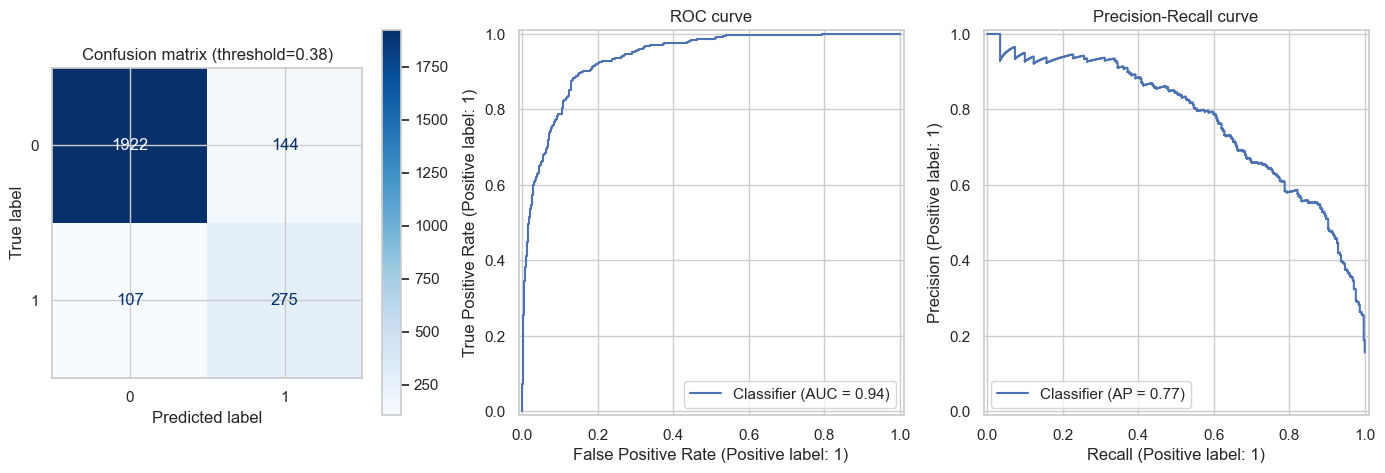

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\final_model_evaluation.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
ConfusionMatrixDisplay.from_predictions(y_test, (proba >= thr).astype(int), ax=axes[0], cmap="Blues")
axes[0].set_title(f"Confusion matrix (threshold={thr:.2f})")
RocCurveDisplay.from_predictions(y_test, proba, ax=axes[1]); axes[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, proba, ax=axes[2]); axes[2].set_title("Precision-Recall curve")
save_fig(fig, "final_model_evaluation")

## 8. Interpretation - which inputs drive the prediction?

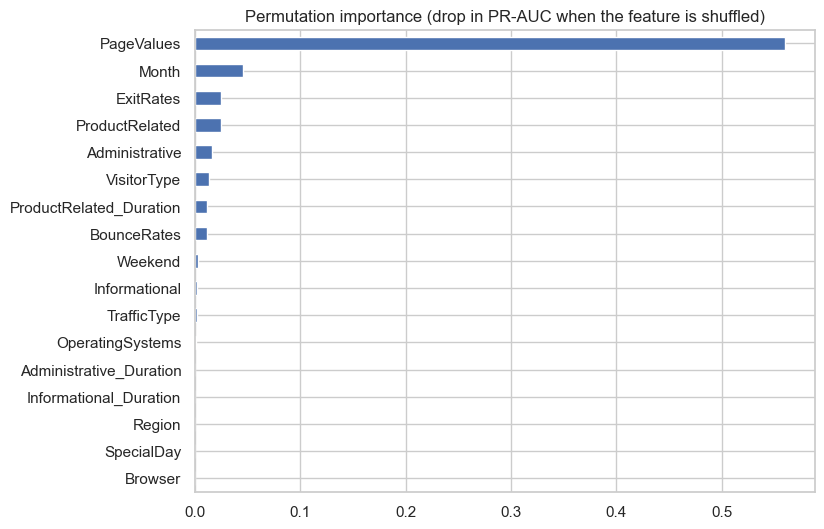

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\final_permutation_importance.png
[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\tables\final_permutation_importance.csv


In [14]:
pi = permutation_importance(pipe, X_test, y_test, scoring="average_precision", n_repeats=10,
                            random_state=RANDOM_STATE, n_jobs=N_JOBS)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values()
fig, ax = plt.subplots(figsize=(8, 6)); imp.plot.barh(ax=ax)
ax.set_title("Permutation importance (drop in PR-AUC when the feature is shuffled)")
save_fig(fig, "final_permutation_importance")
save_table(imp.sort_values(ascending=False).rename("importance").rename_axis("feature").reset_index(),
           "final_permutation_importance")

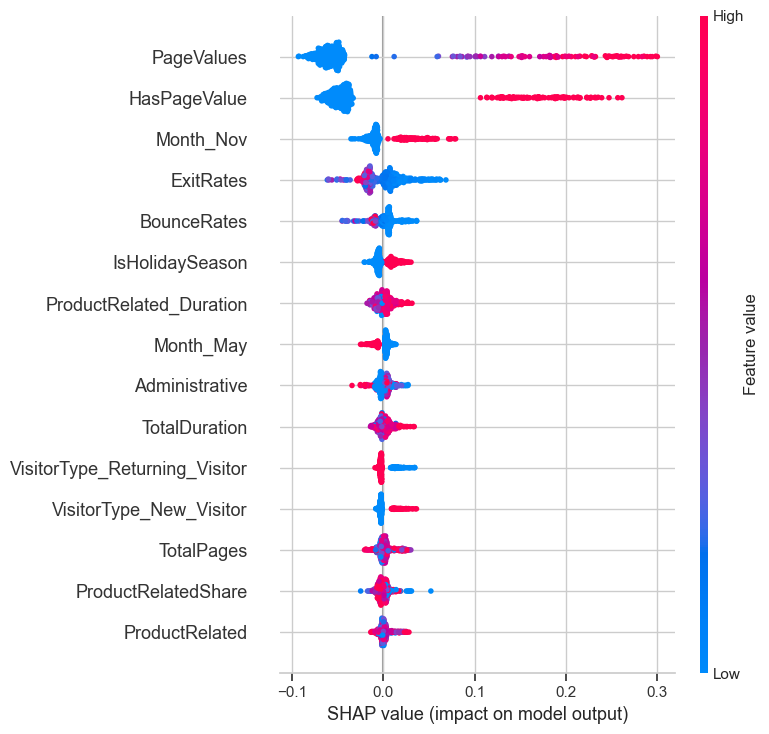

[saved] C:\Users\User\Documents\GitHub\Online-shoppers-purchase-intent\reports\figures\final_shap_summary.png


In [15]:
try:
    import shap
    Xt = pipe[:-1].transform(X_test.sample(500, random_state=RANDOM_STATE))
    names = pipe[:-1].get_feature_names_out()
    sv = shap.TreeExplainer(pipe.named_steps["model"]).shap_values(Xt)
    sv = sv[1] if isinstance(sv, list) else (sv[..., 1] if getattr(sv, "ndim", 2) == 3 else sv)
    shap.summary_plot(sv, Xt, feature_names=list(names), show=False, max_display=15)
    save_fig(plt.gcf(), "final_shap_summary")
except Exception as e:
    print("SHAP skipped:", type(e).__name__, e)

## 9. Save the deployment model
Refit the same tuned pipeline on ALL cleaned data (train+test) and save it. This file is what
`backend/service.py` loads at prediction time.

In [16]:
import joblib
from datetime import datetime

full = load_clean()
deploy = make_final_pipeline().fit(full[FEATURE_COLS], full[TARGET])

artefact = {"pipeline": deploy, "threshold": float(thr), "model_name": name, "prep": BEST_PREP,
            "params": best_params[name], "test_metrics": m_tuned, "feature_columns": FEATURE_COLS,
            "trained_at": datetime.now().isoformat(timespec="seconds")}
joblib.dump(artefact, MODELS_DIR / "final_model.joblib")
joblib.dump({**artefact, "pipeline": pipe}, MODELS_DIR / "final_model_trainonly.joblib")
print("Saved models/final_model.joblib (deployment) and final_model_trainonly.joblib (evaluated above)")
print("Next: uvicorn backend.api:app --port 8000   then   streamlit run frontend/streamlit_app.py")

Saved models/final_model.joblib (deployment) and final_model_trainonly.joblib (evaluated above)
Next: uvicorn backend.api:app --port 8000   then   streamlit run frontend/streamlit_app.py
